In [1]:
import xarray as xr
import data_preparation
from pathlib import Path
import os
from omegaconf import DictConfig
import numpy as np
import matplotlib.pyplot as plt
import time
import logging
import pandas as pd
import torch


In [2]:
v1_inputs = [
    "state_t",
    "state_q0001",
    "state_ps",
    "pbuf_SOLIN",
    "pbuf_LHFLX",
    "pbuf_SHFLX",
]
v1_targets = [
    "ptend_t",
    "ptend_q0001",
    "cam_out_NETSW",
    "cam_out_FLWDS",
    "cam_out_PRECSC",
    "cam_out_PRECC",
    "cam_out_SOLS",
    "cam_out_SOLL",
    "cam_out_SOLSD",
    "cam_out_SOLLD",
]

output_scale_file_path = os.path.join(
    '../../../',
    "preprocessing",
    "normalizations",
    "outputs",
    "output_scale.nc",
)

In [3]:
# base_dir = Path(__file__).resolve().parents[1]
data_path = os.path.join(
    '../../', "unit_test_sets", "dummy_low_res_climsim/", "filename_testing"
)

dataset_config = DictConfig(
    {
        "base_folder_path": data_path,
        "target_years": ["0001"],
        "target_months": ["02"],
        "sample_rate": 1,
    }
)
dataset = data_preparation.ClimSimFromRawDataset(
    mode="train",
    dataset_testing_type="qt",
    dataset_cfg=dataset_config,
    model=None,
    unit_test_specific_methods=True,
)
input_filenames, target_filenames = dataset._get_dataset_filenames(
    base_folder_path=dataset_config.base_folder_path,
    target_years=dataset_config.target_years,
    target_months=dataset_config.target_months,
)
input_ds, target_ds = dataset._combine_datasets(
    input_filenames,
    target_filenames,
    v1_inputs=v1_inputs,
    v1_targets=v1_targets,
)

input_ds, target_ds = dataset._spatial_selection(input_ds, target_ds, "/home/users/bradlesc/projects/ClimSim/grid_info/ClimSim_low-res_grid-info.nc")

input_ds, target_ds, normalisation_stats = dataset._normalise_datasets(
    None,
    input_ds,
    target_ds,
    output_scale_file_path=output_scale_file_path,
    v1_targets=v1_targets,
)



In [4]:


# set the top 15 levels of state_q0001 to zero
input_ds["state_q0001"] = input_ds["state_q0001"].where(
    input_ds["state_q0001"].lev < input_ds["state_q0001"].lev[-15],
    0.0
)

In [5]:
print(input_ds['state_q0001'].shape)
input_ds['state_q0001'][0, :, 0].values

(2, 60, 192)


array([ 2.22173138e-01,  2.10635750e-01,  3.57683546e-01,  7.98097095e-03,
       -3.39565396e-02, -1.38797195e-01, -2.34190430e-01, -2.94891735e-01,
       -3.98326417e-01, -3.91549158e-01, -3.85060963e-01, -3.67576883e-01,
       -3.67454520e-01, -3.30637445e-01, -3.18855003e-01, -3.15158092e-01,
       -2.10348991e-01, -2.32491101e-01,  1.28423758e-01,  4.14525323e-02,
        1.94430412e-01,  3.01060022e-01,  4.20523120e-01,  5.09140996e-01,
        5.03350473e-01,  5.18480423e-01,  5.02292654e-01,  3.70209279e-01,
        3.10450145e-01,  2.84654566e-01,  2.67930509e-01,  2.24256097e-01,
        1.53326364e-01,  7.96307277e-02,  7.89270149e-05, -5.02566833e-02,
       -7.41048693e-02, -2.71369113e-02,  4.64334204e-02,  8.67379037e-02,
        1.39478256e-01,  1.78534033e-01,  1.93561049e-01,  2.22869725e-01,
        3.24367580e-01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

In [14]:
ds_stacked = input_ds.stack(obs=('sample', 'ncol'))
ds_transposed = ds_stacked.transpose('obs', 'lev')

In [18]:
array = ds_stacked.to_array().transpose("obs", "lev", 'variable')

In [23]:
print(array.shape)

(384, 60, 6)


In [24]:
reshaped_data_padded = np.pad(
            array, ((0, 0), (0, 4), (0, 0)), mode="constant", constant_values=0
        )

In [25]:
print(reshaped_data_padded.shape)
print(reshaped_data_padded[1, :, 0])


(384, 64, 6)
[ 4.05316367e-02  2.55306977e-01  2.00617372e-01  2.09939630e-01
  1.78381591e-01  3.54374118e-04 -2.12599467e-02  3.42258579e-02
  7.88297972e-02  1.00314919e-01  1.37100104e-01  1.51055890e-01
  1.62478366e-01  9.89676083e-02 -4.14822237e-02 -2.13532524e-01
 -3.18978811e-01 -3.48535404e-01 -2.90684806e-01 -2.64005092e-01
 -2.07243787e-01 -1.14669661e-01  4.30761330e-02  1.83265409e-01
  2.63872984e-01  2.96723892e-01  3.14273073e-01  3.32757182e-01
  3.45363203e-01  3.54713341e-01  3.61664602e-01  3.72519586e-01
  3.85878216e-01  3.97233766e-01  4.01553999e-01  4.01575528e-01
  3.85217442e-01  3.59511518e-01  3.44609020e-01  3.49867929e-01
  3.53816521e-01  3.61735782e-01  3.64077982e-01  3.64514796e-01
  3.54247682e-01  3.38802310e-01  3.25534683e-01  3.16951364e-01
  3.10365474e-01  2.95122301e-01  2.93440494e-01  2.91421549e-01
  2.84757938e-01  2.77988957e-01  2.66795740e-01  2.64712786e-01
  2.58743503e-01  2.58918282e-01  2.64807320e-01  2.73902041e-01
  0.00000000

In [5]:
da_list = []
feature_names = []

for varname, da in ds_stacked.data_vars.items():
    # Ensure obs ordering is present
    if 'lev' in da.dims:
        # bring to (lev, obs) view (no copy; xarray reorder)
        da_view = da.transpose('lev', 'obs')
        L = da_view.sizes['lev']
        # name the features for each level
        var_feature_names = [f"{varname}_lev{i}" for i in range(L)]
    else:
        # expand a fake lev dimension of length 1 -> (lev=1, obs)
        da_view = da.expand_dims({'lev': [0]}).transpose('lev', 'obs')
        var_feature_names = [f"{varname}"]

    # set lev coordinate to the feature names so concat produces a feature axis with labels
    da_view = da_view.assign_coords({'lev': var_feature_names})
    # rename lev into 'feature' so concat dims match; we'll convert dim name after concat
    da_view = da_view.rename({'lev': 'feature'})
    da_list.append(da_view)
    feature_names.extend(var_feature_names)

# 2) Concatenate all (feature, obs) DataArrays along 'feature' (still lazy if dask)
combined = xr.concat(da_list, dim='feature')

# Ensure feature coordinate is the string list (concat should have done this, but ensure)
combined = combined.assign_coords(feature=("feature", feature_names))

combined = combined.transpose('obs', 'feature')



In [6]:
combined = combined.astype('float32')

# compute once (may be large)
arr = combined.data.compute()   # returns numpy array if small enough

# ensure contiguous and owned
arr = np.ascontiguousarray(arr)

tensor = torch.from_numpy(arr)  # zero-copy if arr owns its data & is C-contiguous

In [7]:
tensor.shape

torch.Size([768, 124])

In [23]:
ds = target_ds * out_scale
for var in target_ds.data_vars:
    target_val = target_ds[var]
    scale_val = out_scale[var]

    print(target_val.values[0, 0, 0], scale_val.values[0], target_val.values[0, 0, 0] * scale_val.values[0])
    break



nan 1004.64 nan


In [13]:
print("=== TARGET VARIABLE STATS ===")
for var in target_ds.data_vars:
    da = target_ds[var]
    print(f"\n{var}:")
    print("  shape:", da.shape)
    print("  dtype:", da.dtype)
    print("  min / max / mean:", float(da.min()), float(da.max()), float(da.mean()))
    print(f"{var}: nan={int(da.isnull().sum())}, inf={int(np.isinf(da).sum())}")
    print(da.isel(sample=0).values.ravel()[:10])


=== TARGET VARIABLE STATS ===

ptend_t:
  shape: (2, 60, 384)
  dtype: float64
  min / max / mean: -0.40420220220530434 0.7770015798330643 -0.0010837315637737177
ptend_t: nan=0, inf=0
[-0.01389134 -0.00876616 -0.02257696 -0.01960585 -0.01012092 -0.01853356
 -0.0141147  -0.01953682 -0.01582567 -0.01386968]

ptend_q0001:
  shape: (2, 60, 384)
  dtype: float64
  min / max / mean: -1.5814201901330185 1.1217528145032765 -0.00841498496062168
ptend_q0001: nan=0, inf=0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

cam_out_NETSW:
  shape: (2, 384)
  dtype: float64
  min / max / mean: 0.0 2.3337916362067244 0.38281974425546794
cam_out_NETSW: nan=0, inf=0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

cam_out_FLWDS:
  shape: (2, 384)
  dtype: float64
  min / max / mean: 0.6496686494777472 2.216504730099772 1.6886684375103858
cam_out_FLWDS: nan=0, inf=0
[1.74782163 1.67602043 2.0085467  2.00115089 1.60980235 1.87792455
 2.06843978 2.08558064 1.91184543 1.77843232]

cam_out_PRECSC:
  shape: (2, 384)
  dtype: float64
  min / 

In [4]:
range_ds = normalisation_stats['range']
np.prod((range_ds == 0).any().to_array()).values # Ensure no zero ranges

array(0)

In [20]:
print("=== INPUT VARIABLE STATS ===")
for var in input_ds.data_vars:
    da = input_ds[var]
    print(f"\n{var}:")
    print("  shape:", da.shape)
    print("  dtype:", da.dtype)
    print("  min / max / mean:", float(da.min()), float(da.max()), float(da.mean()))
    print(f"{var}: nan={int(da.isnull().sum())}, inf={int(np.isinf(da).sum())}")
    print(da.isel(sample=0).values.ravel()[:10])


# for var in target_ds.data_vars:
#     print(f"Target variable: {var}, shape: {target_ds[var].shape}")


=== INPUT VARIABLE STATS ===

state_t:
  shape: (2, 60, 384)
  dtype: float64
  min / max / mean: -0.712445132890337 0.6572075975112113 3.947459643111668e-17
state_t: nan=0, inf=0
[-0.16364995 -0.18641562 -0.04416767 -0.01996718 -0.07155613  0.07054229
  0.03792274  0.11178607  0.01419862 -0.03717115]

state_q0001:
  shape: (2, 60, 384)
  dtype: float64
  min / max / mean: -0.5167189497839824 0.8313661573268584 1.6132928326584307e-17
state_q0001: nan=0, inf=0
[ 0.03195657  0.05299107 -0.01298852 -0.01369328  0.09976864  0.27672239
  0.05275564  0.24167438  0.42642673  0.44773023]

state_ps:
  shape: (2, 384)
  dtype: float64
  min / max / mean: -0.8458048953740004 0.15419510462599956 7.921903873627419e-17
state_ps: nan=0, inf=0
[0.09263426 0.10321856 0.01773145 0.07998143 0.09603724 0.09089112
 0.09011962 0.09881443 0.08278181 0.05230461]

pbuf_SOLIN:
  shape: (2, 384)
  dtype: float64
  min / max / mean: -0.2512312945327568 0.7487687054672432 1.3877787807814457e-17
pbuf_SOLIN: nan=0, 

Plotting INPUT dataset histograms...


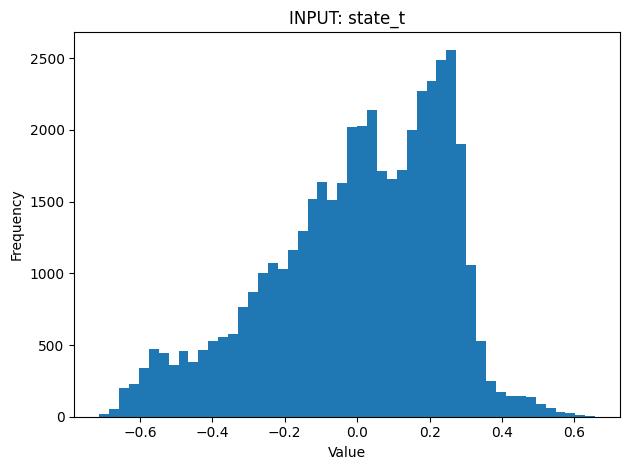

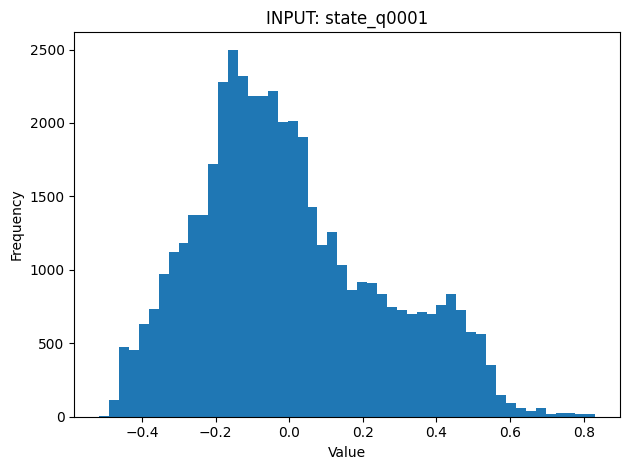

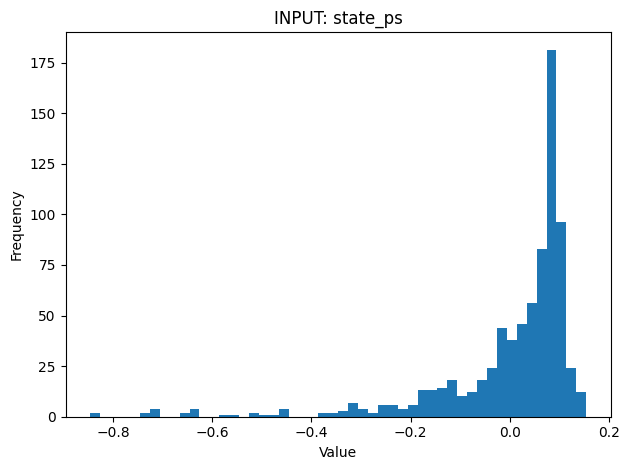

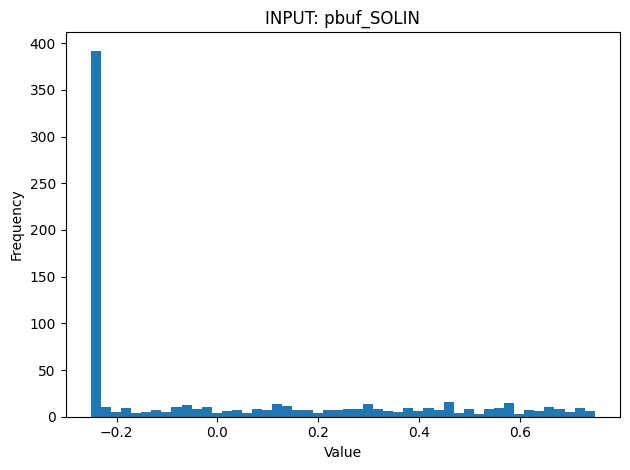

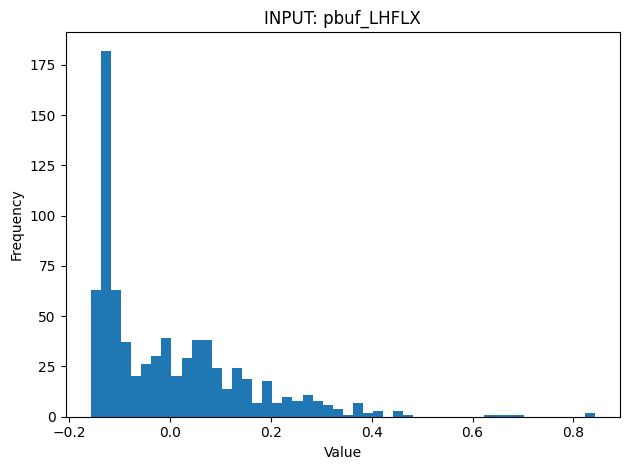

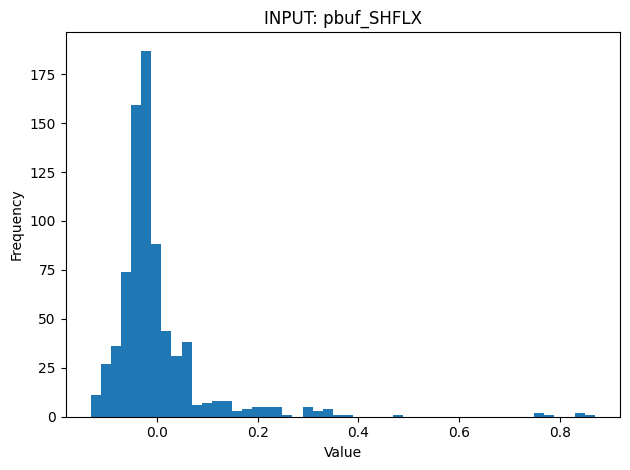

In [24]:
def plot_histograms(ds, title_prefix=""):
    """Plot histograms for all variables in a Dataset."""
    for var in ds.data_vars:
        da = ds[var]

        # Convert to 1D NumPy array
        # (This may trigger a Dask load, so use minimal sampling if needed)
        arr = da.values.ravel()

        # Optional: subsample very large arrays to speed up plotting
        if arr.size > 2_000_000:
            step = max(arr.size // 1_000_000, 1)
            arr = arr[::step]

        # Create figure
        plt.figure()
        plt.hist(arr, bins=50)
        plt.title(f"{title_prefix}{var}")
        plt.xlabel("Value")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()


# ==== Run histograms for both datasets ====

print("Plotting INPUT dataset histograms...")
plot_histograms(input_ds, title_prefix="INPUT: ")

=== TARGET VARIABLE STATS ===

ptend_t:
  shape: (2, 60, 384)
  dtype: float64
  min / max / mean: nan nan nan
ptend_t: nan=46080, inf=0
[nan nan nan nan nan nan nan nan nan nan]

ptend_q0001:
  shape: (2, 60, 384)
  dtype: float64
  min / max / mean: nan nan nan
ptend_q0001: nan=46080, inf=0
[nan nan nan nan nan nan nan nan nan nan]

cam_out_NETSW:
  shape: (2, 384)
  dtype: float64
  min / max / mean: 0.0 2.3337916362067244 0.38281974425546794
cam_out_NETSW: nan=0, inf=0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

cam_out_FLWDS:
  shape: (2, 384)
  dtype: float64
  min / max / mean: 0.6496686494777472 2.216504730099772 1.6886684375103858
cam_out_FLWDS: nan=0, inf=0
[1.74782163 1.67602043 2.0085467  2.00115089 1.60980235 1.87792455
 2.06843978 2.08558064 1.91184543 1.77843232]

cam_out_PRECSC:
  shape: (2, 384)
  dtype: float64
  min / max / mean: 0.0 1.1672397284564924 0.03996089013722314
cam_out_PRECSC: nan=0, inf=0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

cam_out_PRECC:
  shape: (2, 384)
  dtype: flo